In [12]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset
df = pd.read_csv('T1.csv')

# Show first 5 rows
df.head()

,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
0,01 01 2018 00:00,380.047791,5.311336,416.328908,259.994904
1,01 01 2018 00:10,453.769196,5.672167,519.917511,268.641113
2,01 01 2018 00:20,306.376587,5.216037,390.900016,272.564789
3,01 01 2018 00:30,419.645905,5.659674,516.127569,271.258087
4,01 01 2018 00:40,380.650696,5.577941,491.702972,265.674286


In [13]:
# Convert Date/Time to datetime and set as index
df['Date/Time'] = pd.to_datetime(df['Date/Time'], format='%d %m %Y %H:%M', errors='coerce')
df = df.set_index('Date/Time')

# Sort index just in case
df = df.sort_index()

# Rename columns for easy use
df.columns = ['Power', 'WindSpeed', 'TheoreticalPower', 'WindDirection']

df.head()

,Power,WindSpeed,TheoreticalPower,WindDirection
Date/Time,,,,
2018-01-01 00:00:00,380.047791,5.311336,416.328908,259.994904
2018-01-01 00:10:00,453.769196,5.672167,519.917511,268.641113
2018-01-01 00:20:00,306.376587,5.216037,390.900016,272.564789
2018-01-01 00:30:00,419.645905,5.659674,516.127569,271.258087
2018-01-01 00:40:00,380.650696,5.577941,491.702972,265.674286


In [14]:
#TASK 1

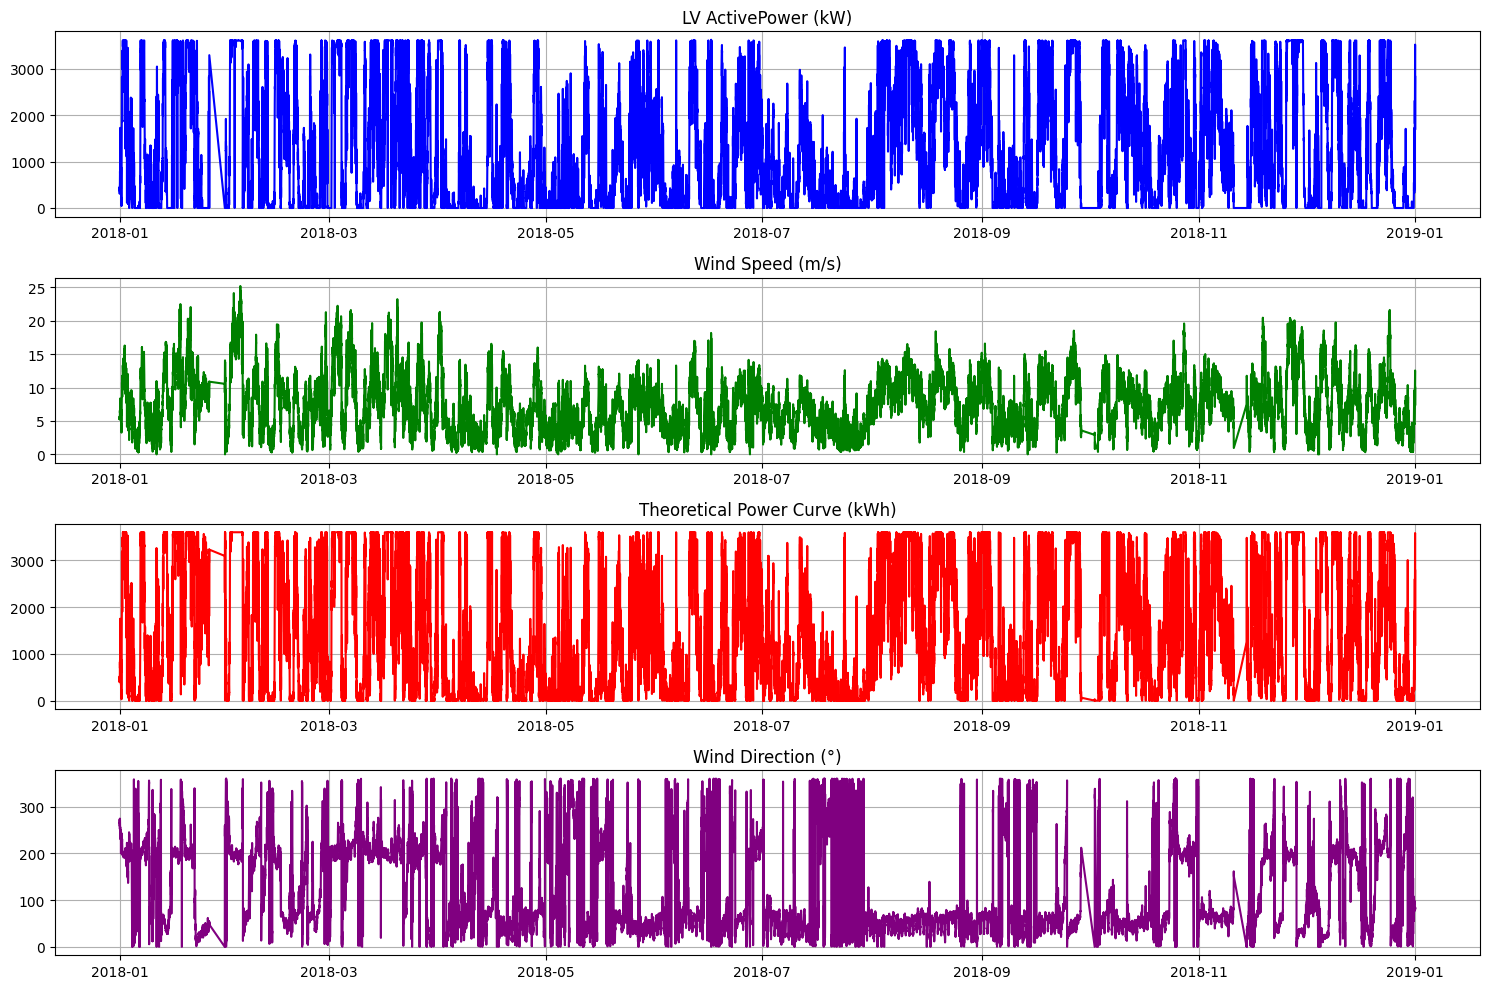

In [15]:
plt.figure(figsize=(15,10))

plt.subplot(4,1,1)
plt.plot(df.index, df['Power'], color='blue')
plt.title('LV ActivePower (kW)')
plt.grid()

plt.subplot(4,1,2)
plt.plot(df.index, df['WindSpeed'], color='green')
plt.title('Wind Speed (m/s)')
plt.grid()

plt.subplot(4,1,3)
plt.plot(df.index, df['TheoreticalPower'], color='red')
plt.title('Theoretical Power Curve (kWh)')
plt.grid()

plt.subplot(4,1,4)
plt.plot(df.index, df['WindDirection'], color='purple')
plt.title('Wind Direction (°)')
plt.grid()

plt.tight_layout()
plt.show()

In [16]:
df.isnull().sum()

,0
Power,0
WindSpeed,0
TheoreticalPower,0
WindDirection,0


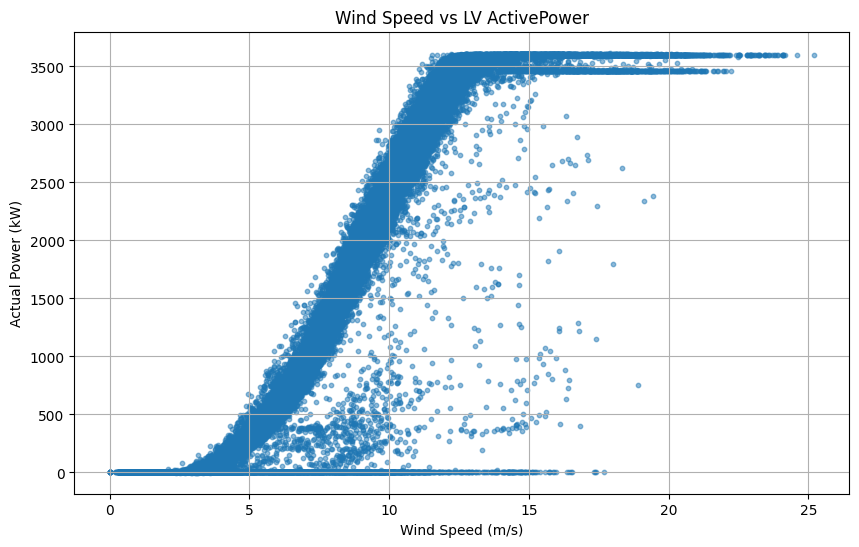

In [17]:
plt.figure(figsize=(10,6))
plt.scatter(df['WindSpeed'], df['Power'], alpha=0.5, s=10)
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Actual Power (kW)')
plt.title('Wind Speed vs LV ActivePower')
plt.grid()
plt.show()

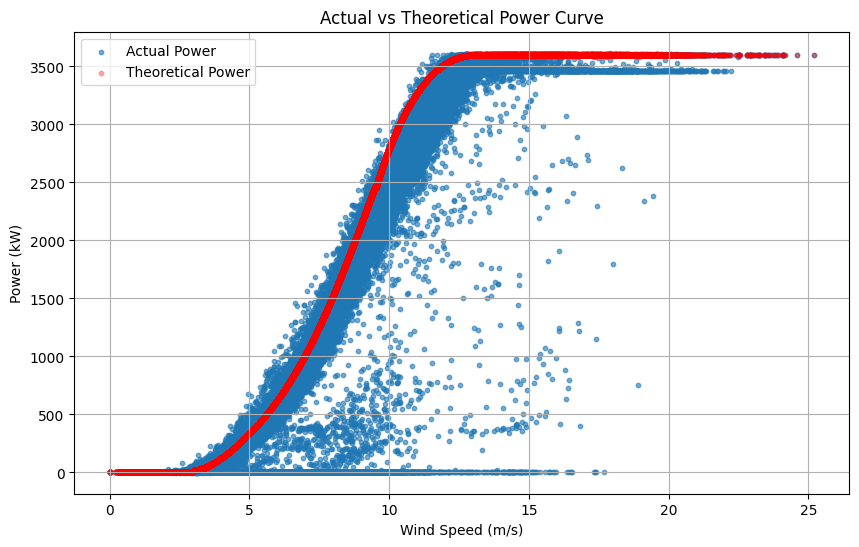

In [18]:
plt.figure(figsize=(10,6))
plt.scatter(df['WindSpeed'], df['Power'], alpha=0.6, label='Actual Power', s=10)
plt.scatter(df['WindSpeed'], df['TheoreticalPower'], color='red', alpha=0.3, label='Theoretical Power', s=10)
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power (kW)')
plt.title('Actual vs Theoretical Power Curve')
plt.legend()
plt.grid()
plt.show()

In [19]:
#TASK 2
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense
import numpy as np

# Select only numeric columns
data = df[['Power', 'WindSpeed', 'TheoreticalPower', 'WindDirection']].copy()

# Fill small missing gaps (if any)
data = data.interpolate()

# Scale data
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# Create sequences (window = 24 → predict next 1 step)
def create_sequences(data, window=24):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled, window=24)

# Train-test split (last 10% as test)
split = int(0.9 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (45455, 24, 4)
Testing samples: (5051, 24, 4)


In [11]:
# Build LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(24, 4)))
model.add(LSTM(50))
model.add(Dense(4))  # 4 outputs
model.compile(optimizer='adam', loss='mse')

# Train (quick)
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=1)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1279/1279 ━━━━━━━━━━━━━━━━━━━━ 32s 23ms/step - loss: 0.0155 - val_loss: 0.0067
Epoch 2/20
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 28s 22ms/step - loss: 0.0061 - val_loss: 0.0065
Epoch 3/20
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - loss: 0.0056 - val_loss: 0.0064
Epoch 4/20
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 42s 23ms/step - loss: 0.0055 - val_loss: 0.0062
Epoch 5/20
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 40s 22ms/step - loss: 0.0057 - val_loss: 0.0061
Epoch 6/20
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 28s 22ms/step - loss: 0.0054 - val_loss: 0.0060
Epoch 7/20
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 42s 23ms/step - loss: 0.0055 - val_loss: 0.0060
Epoch 8/20
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 29s 23ms/step - loss: 0.0055 - val_loss: 0.0060
Epoch 9/20
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 41s 23ms/step - loss: 0.0055 - val_loss: 0.0062
Epoch 10/20
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 29s 22ms/step - loss: 0.0054 - val_loss: 0.0059
Epoch 11/20
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - loss: 0.0053 - val_loss: 0.0061
Epoch 12/20
1279/12

In [20]:
# Predict
y_pred_scaled = model.predict(X_test)

# Reverse scaling
y_pred = scaler.inverse_transform(y_pred_scaled)
y_actual = scaler.inverse_transform(y_test)

# Create result dataframe
import pandas as pd
results = pd.DataFrame({
    'Actual_Power': y_actual[:,0],
    'Pred_Power': y_pred[:,0],
    'Actual_WindSpeed': y_actual[:,1],
    'Pred_WindSpeed': y_pred[:,1],
    'Actual_TheoPower': y_actual[:,2],
    'Pred_TheoPower': y_pred[:,2],
    'Actual_Direction': y_actual[:,3],
    'Pred_Direction': y_pred[:,3]
}, index=df.index[split+24:split+24+len(y_test)])

158/158 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


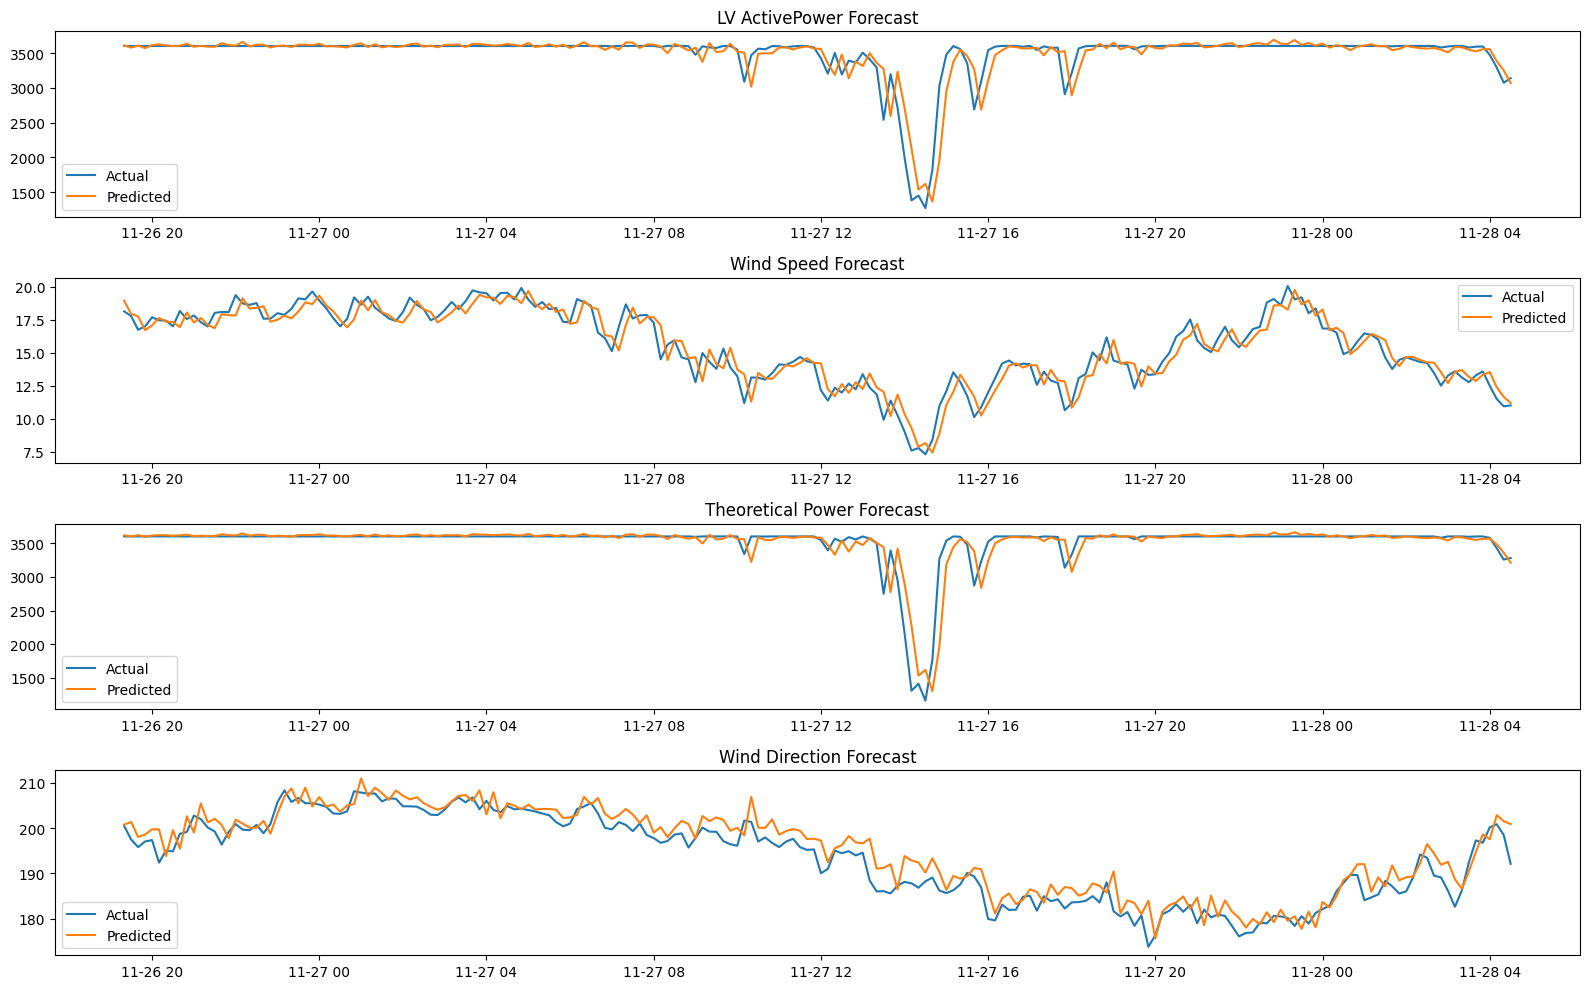

In [21]:
# Plot predictions vs actual (first 200 points)
n = 200
plt.figure(figsize=(16,10))

plt.subplot(4,1,1)
plt.plot(results.index[:n], results.Actual_Power[:n], label='Actual')
plt.plot(results.index[:n], results.Pred_Power[:n], label='Predicted')
plt.title('LV ActivePower Forecast')
plt.legend()

plt.subplot(4,1,2)
plt.plot(results.index[:n], results.Actual_WindSpeed[:n], label='Actual')
plt.plot(results.index[:n], results.Pred_WindSpeed[:n], label='Predicted')
plt.title('Wind Speed Forecast')
plt.legend()

plt.subplot(4,1,3)
plt.plot(results.index[:n], results.Actual_TheoPower[:n], label='Actual')
plt.plot(results.index[:n], results.Pred_TheoPower[:n], label='Predicted')
plt.title('Theoretical Power Forecast')
plt.legend()

plt.subplot(4,1,4)
plt.plot(results.index[:n], results.Actual_Direction[:n], label='Actual')
plt.plot(results.index[:n], results.Pred_Direction[:n], label='Predicted')
plt.title('Wind Direction Forecast')
plt.legend()

plt.tight_layout()
plt.show()

In [23]:
#Error Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("="*50)
print("        TIME-SERIES FORECASTING RESULTS")
print("="*50)

mae_power = mean_absolute_error(results.Actual_Power, results.Pred_Power)
mae_speed = mean_absolute_error(results.Actual_WindSpeed, results.Pred_WindSpeed)
mae_theo  = mean_absolute_error(results.Actual_TheoPower, results.Pred_TheoPower)
mae_dir   = mean_absolute_error(results.Actual_Direction, results.Pred_Direction)

rmse_power = np.sqrt(mean_squared_error(results.Actual_Power, results.Pred_Power))
rmse_speed = np.sqrt(mean_squared_error(results.Actual_WindSpeed, results.Pred_WindSpeed))
rmse_theo  = np.sqrt(mean_squared_error(results.Actual_TheoPower, results.Pred_TheoPower))
rmse_dir   = np.sqrt(mean_squared_error(results.Actual_Direction, results.Pred_Direction))

print(f"{'Variable':<20} {'MAE':<10} {'RMSE':<10}")
print("-"*50)
print(f"{'LV ActivePower (kW)':<20} {mae_power:<10.2f} {rmse_power:<10.2f}")
print(f"{'Wind Speed (m/s)':<20} {mae_speed:<10.2f} {rmse_speed:<10.2f}")
print(f"{'Theoretical Power':<20} {mae_theo:<10.2f} {rmse_theo:<10.2f}")
print(f"{'Wind Direction (°)':<20} {mae_dir:<10.2f} {rmse_dir:<10.2f}")
print("-"*50)

        TIME-SERIES FORECASTING RESULTS
Variable             MAE        RMSE      
--------------------------------------------------
LV ActivePower (kW)  113.89     202.76    
Wind Speed (m/s)     0.56       0.76      
Theoretical Power    146.55     248.73    
Wind Direction (°)   11.64      33.66     
--------------------------------------------------


In [24]:
#TASK 3

In [25]:
# Calculate deviation
df['Deviation'] = df['TheoreticalPower'] - df['Power']

# Anomaly = actual power much lower than theoretical
threshold = df['Deviation'].quantile(0.95)  # Top 5% worst cases
df['Is_Anomaly'] = df['Deviation'] > threshold

print("Total anomalies detected:", df['Is_Anomaly'].sum())

Total anomalies detected: 2527


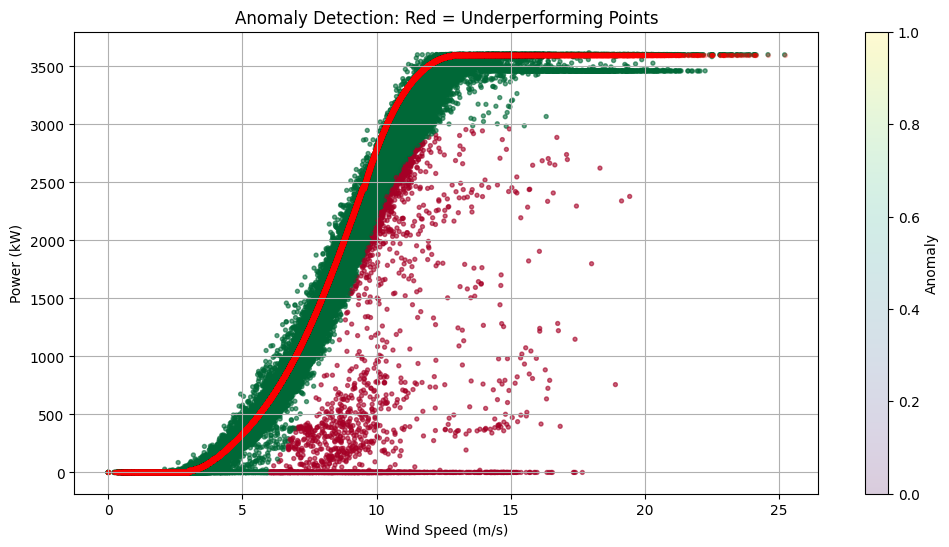

In [26]:
# Visualize anomalies
plt.figure(figsize=(12,6))
plt.scatter(df.WindSpeed, df.Power, c=df.Is_Anomaly, cmap='RdYlGn_r', alpha=0.6, s=8)
plt.scatter(df.WindSpeed, df.TheoreticalPower, color='red', alpha=0.2, s=8)
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power (kW)')
plt.title('Anomaly Detection: Red = Underperforming Points')
plt.colorbar(label='Anomaly')
plt.grid()
plt.show()

In [27]:
#TASK 4

In [28]:
# Performance ratio
df['Perf_Ratio'] = df['Power'] / (df['TheoreticalPower'] + 0.01)
df['Perf_Ratio'] = df['Perf_Ratio'].clip(0, 1.5)

# Score 0 to 100
df['Score'] = (df['Perf_Ratio'] * 100).round(0).astype(int)

# Categorize
df['Status'] = pd.cut(df['Score'],
                      bins=[0, 60, 85, 100],
                      labels=['Poor', 'Moderate', 'Good'])

# Suggestions
def give_suggestion(row):
    if row['Status'] == 'Good':
        return 'Excellent performance. Keep up maintenance.'
    elif row['Status'] == 'Moderate':
        return 'Check blades for dirt, yaw system, minor issues.'
    else:
        return 'URGENT: Major fault possible - blades, gearbox, or generator.'

df['Suggestion'] = df.apply(give_suggestion, axis=1)

# Show sample
df[['Power', 'TheoreticalPower', 'Score', 'Status', 'Suggestion']].head(10)

,Power,TheoreticalPower,Score,Status,Suggestion
Date/Time,,,,,
2018-01-01 00:00:00,380.047791,416.328908,91,Good,Excellent performance. Keep up maintenance.
2018-01-01 00:10:00,453.769196,519.917511,87,Good,Excellent performance. Keep up maintenance.
2018-01-01 00:20:00,306.376587,390.900016,78,Moderate,"Check blades for dirt, yaw system, minor issues."
2018-01-01 00:30:00,419.645905,516.127569,81,Moderate,"Check blades for dirt, yaw system, minor issues."
2018-01-01 00:40:00,380.650696,491.702972,77,Moderate,"Check blades for dirt, yaw system, minor issues."
2018-01-01 00:50:00,402.391998,499.436385,81,Moderate,"Check blades for dirt, yaw system, minor issues."
2018-01-01 01:00:00,447.605713,557.372363,80,Moderate,"Check blades for dirt, yaw system, minor issues."
2018-01-01 01:10:00,387.242188,414.898179,93,Good,Excellent performance. Keep up maintenance.
2018-01-01 01:20:00,463.651215,493.677652,94,Good,Excellent performance. Keep up maintenance.


In [29]:
# Summary
print(df['Status'].value_counts())
print("\nAverage Performance Score:", df['Score'].mean().round(1), "/ 100")

Status
Good        22244
Moderate    11359
Poor         2046
Name: count, dtype: int64

Average Performance Score: 69.7 / 100
